<a href="https://colab.research.google.com/github/VasudevAdhikari/depression-detection/blob/main/colab/RealModelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive
import seaborn as sns
from sklearn.cluster import OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from scipy.special import softmax

import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

from torch.nn.utils.rnn import pad_sequence
import re

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
label_files = os.listdir('drive/MyDrive/DaicLabels')

In [ ]:
label_list = []

base_columns = ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender']
other_columns = ['PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Sleep']

all_columns = base_columns + other_columns

for label_file in label_files:
    df = pd.read_csv(f"drive/MyDrive/DaicLabels/{label_file}")
    print(df.columns.tolist())

    # Add missing optional columns as NaN
    for col in other_columns:
        if col not in df.columns:
            df[col] = np.nan

    # Ensure all required columns exist
    label_list.append(df[all_columns])

labels = pd.concat(label_list, ignore_index=True)

['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']
['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender']
['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']


In [ ]:
len(labels.Participant_ID.unique())

190

In [ ]:
labels.describe()

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_Tired,PHQ8_Appetite,PHQ8_Sleep
count,189.000000,189.000000,189.000000,189.000000,142.000000,142.000000,141.000000
mean,395.947090,0.296296,6.746032,0.539683,1.105634,0.957746,1.063830
std,56.117822,0.457836,5.924081,0.499747,0.958040,1.037408,1.070466
min,300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,348.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,396.000000,0.000000,5.000000,1.000000,1.000000,1.000000,1.000000
75%,444.000000,1.000000,10.000000,1.000000,2.000000,2.000000,2.000000
max,492.000000,1.000000,23.000000,1.000000,3.000000,3.000000,3.000000


                Participant_ID  PHQ8_Binary  PHQ8_Score    Gender  PHQ8_Tired  \
Participant_ID        1.000000    -0.227947   -0.239321 -0.094568   -0.211603   
PHQ8_Binary          -0.227947     1.000000    0.841770 -0.121405    0.639469   
PHQ8_Score           -0.239321     0.841770    1.000000 -0.098989    0.798977   
Gender               -0.094568    -0.121405   -0.098989  1.000000   -0.168451   
PHQ8_Tired           -0.211603     0.639469    0.798977 -0.168451    1.000000   
PHQ8_Appetite        -0.194453     0.713112    0.777120 -0.159909    0.568257   
PHQ8_Sleep           -0.231062     0.679109    0.778095 -0.079958    0.694342   

                PHQ8_Appetite  PHQ8_Sleep  
Participant_ID      -0.194453   -0.231062  
PHQ8_Binary          0.713112    0.679109  
PHQ8_Score           0.777120    0.778095  
Gender              -0.159909   -0.079958  
PHQ8_Tired           0.568257    0.694342  
PHQ8_Appetite        1.000000    0.547240  
PHQ8_Sleep           0.547240    1.000000  

<Axes: >

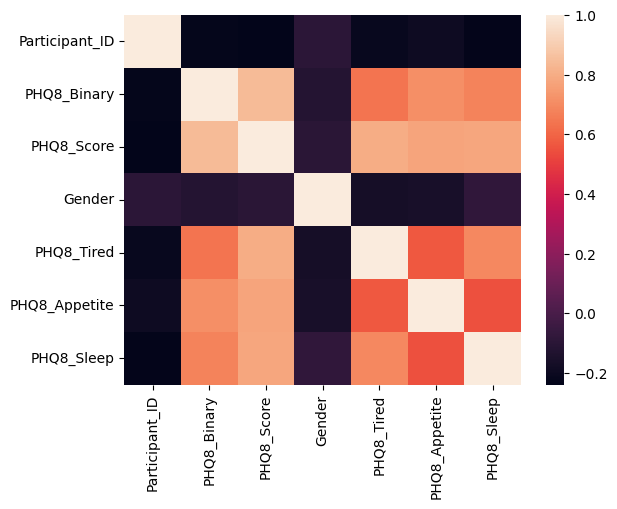

In [ ]:
print(labels.corr())
sns.heatmap(labels.corr())

In [ ]:
numeric_cols = labels.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Participant_ID')

In [ ]:
imputer = KNNImputer(n_neighbors=7)
labels[numeric_cols] = imputer.fit_transform(labels[numeric_cols])
labels[numeric_cols] = np.round(labels[numeric_cols])
labels.corr()

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_Tired,PHQ8_Appetite,PHQ8_Sleep
Participant_ID,1.000000,-0.227947,-0.239321,-0.094568,-0.221340,-0.194248,-0.221143
PHQ8_Binary,-0.227947,1.000000,0.803069,-0.213805,0.665989,0.712810,0.700985
PHQ8_Score,-0.239321,0.803069,1.000000,-0.084195,0.816455,0.812902,0.811764
Gender,-0.094568,-0.213805,-0.084195,1.000000,-0.150825,-0.127302,-0.051672
PHQ8_Tired,-0.221340,0.665989,0.816455,-0.150825,1.000000,0.627816,0.719628
PHQ8_Appetite,-0.194248,0.712810,0.812902,-0.127302,0.627816,1.000000,0.620837
PHQ8_Sleep,-0.221143,0.700985,0.811764,-0.051672,0.719628,0.620837,1.000000


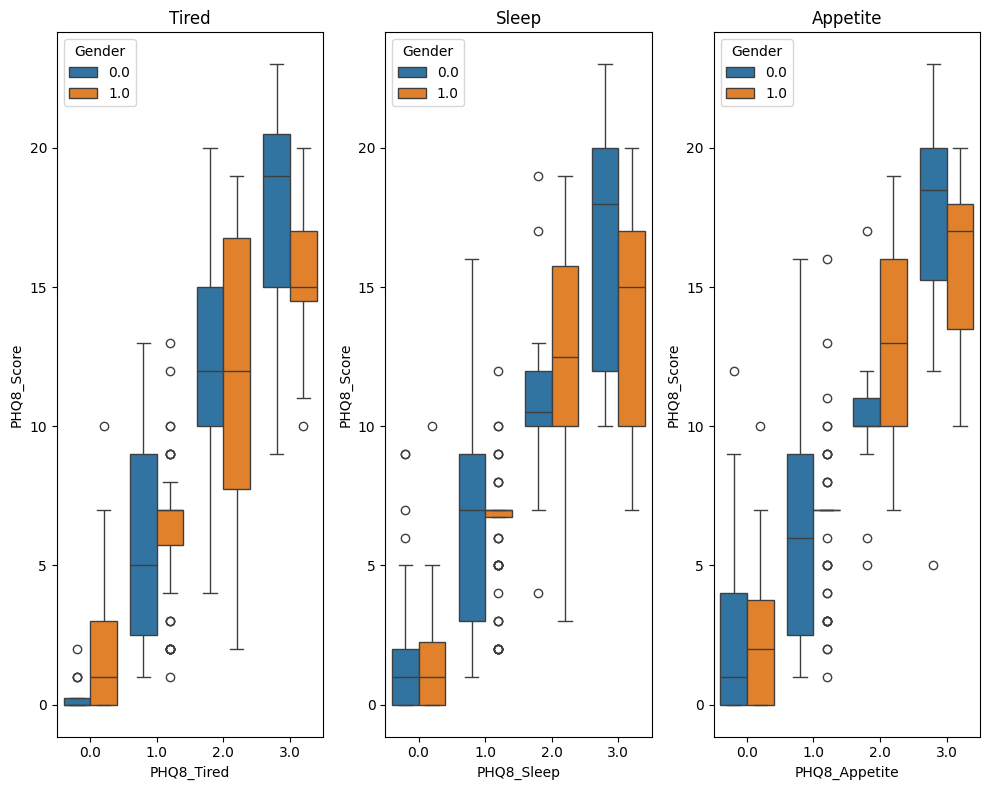

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 8))

sns.boxplot(data=labels, x='PHQ8_Tired', y='PHQ8_Score', hue='Gender', ax=axes[0])
axes[0].set_title("Tired")

sns.boxplot(data=labels, x='PHQ8_Sleep', y='PHQ8_Score', hue='Gender', ax=axes[1])
axes[1].set_title("Sleep")

sns.boxplot(data=labels, x='PHQ8_Appetite', y='PHQ8_Score', hue='Gender', ax=axes[2])
axes[2].set_title("Appetite")

plt.tight_layout()
plt.show()

<Axes: xlabel='PHQ8_Tired', ylabel='PHQ8_Score'>

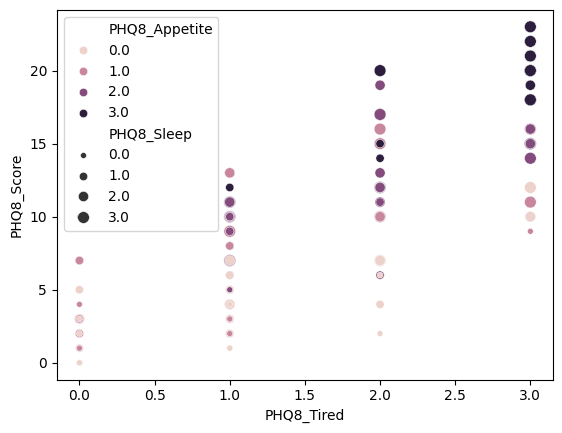

In [ ]:
sns.scatterplot(data=labels, x='PHQ8_Tired', y='PHQ8_Score', hue='PHQ8_Appetite', size='PHQ8_Sleep')

# Sentence NLP Feature Extraction

In [ ]:
# Sentence embedding model
bert_model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name)
bert_model.eval()

# Sentiment model
sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment"
sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_model_name)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_model_name)
sentiment_model.eval()


def extract_sentence_features(sentence):
    """
    Input:
        sentence (str)

    Output:
        dict containing:
            - embedding_mean
            - embedding_median
            - embedding_std
            - embedding_min
            - embedding_max
            - sentiment_score
    """

    # ---------------------------
    # 1️⃣ BERT Embedding
    # ---------------------------
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    # CLS token embedding
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()

    # ---------------------------
    # 2️⃣ Embedding Statistics
    # ---------------------------
    embedding_mean = np.mean(cls_embedding)
    embedding_median = np.median(cls_embedding)
    embedding_std = np.std(cls_embedding)
    embedding_min = np.min(cls_embedding)
    embedding_max = np.max(cls_embedding)

    # ---------------------------
    # 3️⃣ Sentiment Score
    # ---------------------------
    sentiment_inputs = sentiment_tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        sentiment_outputs = sentiment_model(**sentiment_inputs)

    probs = softmax(sentiment_outputs.logits.numpy()[0])

    # For 3-class model:
    # 0 = negative, 1 = neutral, 2 = positive
    sentiment_score = probs[2] - probs[0]  # simple polarity score

    return {
        "embedding_mean": embedding_mean,
        "embedding_median": embedding_median,
        "embedding_std": embedding_std,
        "embedding_min": embedding_min,
        "embedding_max": embedding_max,
        "sentiment_score": sentiment_score
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
sentences = ""
for i in range(30):
  sentences += "I feel very tired lately. I don't feel like eating as well"
features = extract_sentence_features(
    sentences
)
print(features)
print(f'\n{i}==========================')

{'embedding_mean': np.float32(-0.014257353), 'embedding_median': np.float32(-0.033508994), 'embedding_std': np.float32(0.59031796), 'embedding_min': np.float32(-2.7761908), 'embedding_max': np.float32(2.5983984), 'sentiment_score': np.float32(-0.89672434)}

29==========================


In [ ]:
dataframes = {}

for p_id in labels['Participant_ID']:

    # Skip missing values safely (works for None, NaN, etc.)
    if pd.isna(p_id):
        continue

    try:
        # Convert safely to integer
        participant_id = int(float(p_id))

        file_path = f'/content/drive/MyDrive/ProcessedDaicWoz/{participant_id}_processed.csv'

        # Check if file exists
        if not os.path.exists(file_path):
            print(f"File not found for Participant {participant_id}")
            continue

        print(participant_id, "\n=========================")

        data = pd.read_csv(file_path)


        # Apply feature extraction row-wise
        features_series = data['value'].apply(
            lambda x: extract_sentence_features(x)
            if isinstance(x, str) and x.strip() != ""
            else {
                "embedding_mean": np.nan,
                "embedding_median": np.nan,
                "embedding_std": np.nan,
                "embedding_min": np.nan,
                "embedding_max": np.nan,
                "sentiment_score": np.nan
            }
        )

        # Convert list of dicts → DataFrame
        features_df = pd.DataFrame(features_series.tolist())

        # Concatenate safely
        data = pd.concat([data.reset_index(drop=True), features_df], axis=1)

        dictionary = {
            'dataframe': data,
            'gender': labels[labels['Participant_ID']==p_id]['Gender'],
            'sleep': labels[labels['Participant_ID']==p_id]['PHQ8_Sleep'],
            'tired': labels[labels['Participant_ID']==p_id]['PHQ8_Tired'],
            'appetite': labels[labels['Participant_ID']==p_id]['PHQ8_Appetite'],
            'phq8_scoree': labels[labels['Participant_ID']==p_id]['PHQ8_Score'],
        }
        dataframes[f'P_{participant_id}'] = dictionary

    except ValueError:
        print(f"Invalid Participant_ID: {p_id}")
    except Exception as e:
        print(f"Error loading Participant {p_id}: {e}")

302 
307 
331 
335 
346 
367 
377 
381 
382 
388 
389 
390 
395 
403 
404 
406 
413 
417 
418 
420 
422 
436 
439 
440 
451 
458 
472 
476 
477 
482 
483 
484 
489 
490 
492 
300 
301 
306 
308 
309 
311 
314 
323 
329 
332 
File not found for Participant 334
337 
349 
354 
359 
361 
365 
373 
378 
384 
387 
396 
399 
405 
File not found for Participant 407
408 
410 
411 
421 
424 
431 
432 
435 
438 
442 
450 
452 
453 
461 
462 
465 
466 
467 
469 
470 
480 
481 
303 
304 
305 
310 
312 
313 
315 
316 
317 
318 
319 
320 
321 
322 
324 
325 
326 
327 
328 
330 
333 
336 
338 
339 
340 
341 
343 
344 
345 
347 
348 
350 
351 
352 
353 
355 
356 
357 
358 
360 
362 
363 
364 
366 
368 
369 
370 
371 
372 
374 
375 
376 
379 
380 
383 
385 
386 
391 
392 
393 
397 
400 
401 
402 
409 
412 
414 
415 
416 
419 
423 
425 
426 
427 
428 
429 
430 
433 
434 
437 
441 
443 
444 
445 
446 
447 
448 
449 
454 
455 
456 
457 
459 
463 
464 
468 
471 
473 
474 
475 
478 
479 
485 
486 
487 
488 


In [ ]:
import joblib
joblib.dump(dataframes, "/content/drive/MyDrive/daicwoz_features.joblib", compress=3)

NameError: name 'dataframes' is not defined

In [ ]:
import joblib
dataframes = joblib.load("/content/drive/MyDrive/daicwoz_features.joblib")

# Model Training using LSTM

In [ ]:
import os, re, torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# Settings
BATCH_SIZE = 94  # 🔥 Massive increase to fill GPU RAM
LR = 2e-3
DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True

# =====================================================
# 1. ULTRASONIC PRE-PROCESSING (CPU)
# =====================================================
def get_features_for_file(args):
    file_name, folder_path, labels_df = args
    try:
        df = pd.read_csv(os.path.join(folder_path, file_name))
        pid = int(re.search(r'\d+', file_name).group())
        label = labels_df[labels_df["Participant_ID"] == pid]["PHQ8_Score"].values[0]

        # Optimized string handling
        sentences = df["value"].fillna("").astype(str).values
        feats = [list(extract_sentence_features(s).values()) for s in sentences]

        return (torch.tensor(feats, dtype=torch.float32),
                torch.tensor(label, dtype=torch.float32))
    except:
        return None

def load_everything_into_ram(file_list, folder_path, labels_df):
    print(f"🚀 Hammering CPU to pre-process {len(file_list)} files...")
    tasks = [(f, folder_path, labels_df) for f in file_list]

    # Use all CPU cores
    with ProcessPoolExecutor() as executor:
        results = list(tqdm(executor.map(get_features_for_file, tasks), total=len(tasks)))

    # Filter out None results and keep in RAM
    return [r for r in results if r is not None]

# =====================================================
# 2. IN-MEMORY DATASET (Zero Disk I/O during training)
# =====================================================
class RAMDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list # List of (tensor, label) tuples

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# =====================================================
# 3. BIDIRECTIONAL MODEL (Better performance)
# =====================================================
class FastLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, num_layers=2,
                           batch_first=True, bidirectional=True, dropout=0.2)
        self.fc = nn.Linear(64 * 2, 1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        # Cat the final forward and backward hidden states
        out = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(out).squeeze(-1)

# =====================================================
# 4. TRAINING ENGINE
# =====================================================
def collate_fn(batch):
    # Sort by length for slightly faster RNN processing
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    return pad_sequence(seqs, batch_first=True), lengths, torch.stack(labels)

# --- Logic Execution ---
# 1. Load data once
train_data = load_everything_into_ram(train_files, folder_path, labels)
test_data = load_everything_into_ram(test_files, folder_path, labels)

# 2. DataLoaders (high batch size)
train_loader = DataLoader(RAMDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(RAMDataset(test_data), batch_size=BATCH_SIZE, collate_fn=collate_fn)

# 3. Model & Optimizer
model = FastLSTM(train_data[0][0].shape[1]).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
criterion = nn.HuberLoss()
scaler = torch.cuda.amp.GradScaler() # 🔥 Mixed Precision

# 4. Loop
for epoch in range(100):
    model.train()
    for x, lengths, y in train_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(): # 🔥 Use Tensor Cores
            outputs = model(x, lengths)
            loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    print(f"Epoch {epoch+1} complete. GPU RAM Used: {torch.cuda.memory_allocated()/1e9:.2f}GB")

🚀 Hammering CPU to pre-process 150 files...


  0%|          | 0/150 [00:19<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# =====================================================
# Imports
# =====================================================

import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

# =====================================================
# Path
# =====================================================

folder_path = "drive/MyDrive/ProcessedDaicWoz"

# =====================================================
# Get All Files
# =====================================================

file_names = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# =====================================================
# STEP 1: Determine Common Numeric Columns
# (Ensures FIXED feature dimension)
# =====================================================

all_numeric_sets = []

for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if "time" not in col.lower()]

    all_numeric_sets.append(set(numeric_cols))

# Intersection of all files
common_columns = list(set.intersection(*all_numeric_sets))

print("Number of common numeric features:", len(common_columns))

# =====================================================
# STEP 2: Build Feature Matrix
# =====================================================

X = []
y = []

for file_name in file_names:

    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path)

    participant_id = int(re.search(r'\d+', file_name).group())

    row = labels[labels["Participant_ID"] == participant_id]

    if len(row) == 0:
        continue

    label = row["PHQ8_Score"].values[0]

    # Use only common columns
    numeric_df = df[common_columns]

    # Replace NaN with 0
    numeric_df = numeric_df.fillna(0)

    # Aggregate across sentences
    features = []

    features.extend(numeric_df.mean().values)
    features.extend(numeric_df.std().values)
    features.extend(numeric_df.max().values)
    features.extend(numeric_df.min().values)

    X.append(features)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("Final Feature Shape:", X.shape)
print("Final Label Shape:", y.shape)

# =====================================================
# STEP 3: Train / Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# STEP 4: XGBoost Model
# =====================================================

model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=1,
    reg_lambda=5,
    random_state=42,
    objective='reg:squarederror'
)

# =====================================================
# STEP 5: Train
# =====================================================

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

# =====================================================
# STEP 6: Evaluate
# =====================================================

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("Evaluation Results")
print("==============================")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Number of common numeric features: 160
Final Feature Shape: (188, 640)
Final Label Shape: (188,)
[0]	validation_0-rmse:6.45579
[1]	validation_0-rmse:6.45944
[2]	validation_0-rmse:6.45855
[3]	validation_0-rmse:6.46012
[4]	validation_0-rmse:6.46627
[5]	validation_0-rmse:6.45736
[6]	validation_0-rmse:6.45432
[7]	validation_0-rmse:6.45517
[8]	validation_0-rmse:6.45411
[9]	validation_0-rmse:6.44973
[10]	validation_0-rmse:6.44647
[11]	validation_0-rmse:6.45168
[12]	validation_0-rmse:6.44939
[13]	validation_0-rmse:6.45224
[14]	validation_0-rmse:6.45978
[15]	validation_0-rmse:6.45846
[16]	validation_0-rmse:6.47320
[17]	validation_0-rmse:6.46926
[18]	validation_0-rmse:6.47328
[19]	validation_0-rmse:6.47289
[20]	validation_0-rmse:6.47807
[21]	validation_0-rmse:6.47343
[22]	validation_0-rmse:6.47708
[23]	validation_0-rmse:6.48048
[24]	validation_0-rmse:6.47937
[25]	validation_0-rmse:6.48067
[26]	validation_0-rmse:6.47763
[27]	validation_0-rmse:6.48113
[28]	validation_0-rmse:6.47990
[29]	validatio

In [ ]:
p_300 = pd.read_csv('/content/drive/MyDrive/ProcessedDaicWoz/300_processed.csv')
len(p_300)

87

In [ ]:
# import os
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
# from sklearn.model_selection import train_test_split


# # =====================================================
# # Device Setup (Max GPU Utilization)
# # =====================================================

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"\n🚀 Using Device: {device}")
# if torch.cuda.is_available():
#     print(f"🔥 GPU Name: {torch.cuda.get_device_name(0)}")
#     torch.backends.cudnn.benchmark = True


# # =====================================================
# # Dataset Class
# # =====================================================

# class DepressionDataset(Dataset):
#     def __init__(self, data_dict):
#         self.samples = list(data_dict.values())
#         self.keys = list(data_dict.keys())

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         item = self.samples[idx]
#         df = item['dataframe']

#         # Remove non-numeric columns
#         df = df.select_dtypes(include=[np.number])

#         # Convert to tensor
#         features = torch.tensor(df.values, dtype=torch.float32)

#         # Label (fix typo)
#         label = float(item['phq8_scoree'].iloc[0])

#         return features, torch.tensor(label, dtype=torch.float32)


# # =====================================================
# # Collate Function (Padding + Lengths)
# # =====================================================

# def collate_fn(batch):
#     sequences, labels = zip(*batch)

#     lengths = torch.tensor([len(seq) for seq in sequences])

#     padded_sequences = pad_sequence(sequences, batch_first=True)

#     labels = torch.stack(labels)

#     return padded_sequences, lengths, labels


# # =====================================================
# # LSTM Model (SELU + LeCun Init)
# # =====================================================

# class DepressionLSTM(nn.Module):
#     def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.2):

#         super().__init__()

#         self.lstm = nn.LSTM(
#             input_dim,
#             hidden_dim,
#             num_layers=num_layers,
#             batch_first=True,
#             dropout=dropout
#         )

#         self.fc = nn.Sequential(
#             nn.Linear(hidden_dim, 128),
#             nn.SELU(),
#             nn.AlphaDropout(0.1),
#             nn.Linear(128, 64),
#             nn.SELU(),
#             nn.AlphaDropout(0.1),
#             nn.Linear(64, 1)
#         )

#         self._initialize_weights()

#     def _initialize_weights(self):
#       for m in self.modules():
#           if isinstance(m, nn.Linear):
#               fan_in = m.weight.size(1)
#               std = np.sqrt(1.0 / fan_in)
#               nn.init.normal_(m.weight, mean=0.0, std=std)
#               if m.bias is not None:
#                   nn.init.zeros_(m.bias)

#     def forward(self, x, lengths):

#         packed = pack_padded_sequence(
#             x, lengths.cpu(), batch_first=True, enforce_sorted=False
#         )

#         _, (hidden, _) = self.lstm(packed)

#         out = hidden[-1]

#         return self.fc(out).squeeze()


🚀 Using Device: cuda
🔥 GPU Name: Tesla T4


In [ ]:
# Collect feature columns from each dataframe
feature_sets = []

for item in dataframes.values():
    df = item['dataframe']
    numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
    feature_sets.append(numeric_cols)

# Find intersection (common columns across all participants)
common_columns = set.intersection(*feature_sets)

common_columns = sorted(list(common_columns))

print(f"✅ Common Feature Count: {len(common_columns)}")

for key in dataframes.keys():
    df = dataframes[key]['dataframe']

    # Keep only common columns
    df = df[common_columns]

    # Update dictionary
    dataframes[key]['dataframe'] = df

print("🎯 All datasets now have identical feature dimensions.")


✅ Common Feature Count: 232
🎯 All datasets now have identical feature dimensions.


In [ ]:
# =====================================================
# Imports
# =====================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer


# =====================================================
# Device Setup
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Using Device: {device}")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")


# =====================================================
# Dataset
# =====================================================

class DepressionDataset(Dataset):
    def __init__(self, data_dict):
        self.samples = list(data_dict.values())

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        df = item['dataframe']
        df = df.select_dtypes(include=[np.number])

        features = torch.tensor(df.values, dtype=torch.float32)

        label = float(item['phq8_scoree'].iloc[0])

        return features, torch.tensor(label, dtype=torch.float32)


# =====================================================
# Collate
# =====================================================

def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences])
    padded = pad_sequence(sequences, batch_first=True)
    labels = torch.stack(labels)
    return padded, lengths, labels


# =====================================================
# Log-Cosh Loss
# =====================================================

class LogCoshLoss(nn.Module):
    def forward(self, y_pred, y_true):
        x = y_pred - y_true
        return torch.mean(torch.log(torch.cosh(x + 1e-12)))


# =====================================================
# Depression LSTM (FIXED LeCun)
# =====================================================

class DepressionLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):

        super().__init__()

        # Feature gating
        self.feature_gate = nn.Parameter(torch.ones(input_dim))

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.SELU(),
            nn.AlphaDropout(0.1),
            nn.Linear(128, 64),
            nn.SELU(),
            nn.AlphaDropout(0.1),
            nn.Linear(64, 1)
        )

        self._init_weights()

    # -------------------------
    # Manual LeCun Normal Init
    # -------------------------
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                fan_in = m.weight.size(1)
                std = np.sqrt(1.0 / fan_in)
                nn.init.normal_(m.weight, mean=0.0, std=std)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, lengths):

        # Apply feature importance gate
        x = x * self.feature_gate

        packed = pack_padded_sequence(
            x, lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)

        out = hidden[-1]

        return self.fc(out).squeeze()


# =====================================================
# Training Function
# =====================================================

def train_model(dataframes):

    dataset = DepressionDataset(dataframes)

    train_idx, val_idx = train_test_split(
        range(len(dataset)),
        test_size=0.3,
        random_state=42
    )

    # -------------------------
    # Collect TRAIN DATA ONLY
    # -------------------------

    train_sequences = []
    train_labels = []

    for idx in train_idx:
        x, y = dataset[idx]
        train_sequences.append(x.numpy())
        train_labels.append(y.numpy())

    train_lengths = [len(seq) for seq in train_sequences]

    train_features = np.vstack(train_sequences)

    # -------------------------
    # KNN Imputation (Train Only)
    # -------------------------

    print("\n🧠 KNN Imputation...")
    imputer = KNNImputer(n_neighbors=5)
    train_features = imputer.fit_transform(train_features)

    # -------------------------
    # Standard Scaling
    # -------------------------

    print("📏 Standard Scaling...")
    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_features)

    train_features = np.split(
        train_features,
        np.cumsum(train_lengths[:-1])
    )

    # -------------------------
    # Validation Processing
    # -------------------------

    val_sequences = []
    val_labels = []

    for idx in val_idx:
        x, y = dataset[idx]
        val_sequences.append(x.numpy())
        val_labels.append(y.numpy())

    val_lengths = [len(seq) for seq in val_sequences]

    val_features = np.vstack(val_sequences)
    val_features = imputer.transform(val_features)
    val_features = scaler.transform(val_features)

    val_features = np.split(
        val_features,
        np.cumsum(val_lengths[:-1])
    )

    # -------------------------
    # DataLoaders
    # -------------------------

    class CustomDataset(Dataset):
        def __init__(self, sequences, labels):
            self.sequences = sequences
            self.labels = labels

        def __len__(self):
            return len(self.sequences)

        def __getitem__(self, idx):
            return (
                torch.tensor(self.sequences[idx], dtype=torch.float32),
                torch.tensor(len(self.sequences[idx])),
                torch.tensor(self.labels[idx], dtype=torch.float32)
            )

    train_loader = DataLoader(
        CustomDataset(train_features, train_labels),
        batch_size=4,
        shuffle=True,
        collate_fn=lambda x: collate_fn([(a[0], a[2]) for a in x])
    )

    val_loader = DataLoader(
        CustomDataset(val_features, val_labels),
        batch_size=4,
        shuffle=False,
        collate_fn=lambda x: collate_fn([(a[0], a[2]) for a in x])
    )

    # -------------------------
    # Model
    # -------------------------

    sample_input, _, _ = next(iter(train_loader))
    input_dim = sample_input.shape[2]

    model = DepressionLSTM(input_dim).to(device)

    sentiment_index = 229  # replace with actual index
    model.feature_gate.data[sentiment_index] = 6

    criterion = LogCoshLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=5e-5,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    best_val_loss = float("inf")
    patience = 20
    counter = 0

    print("\n🏋️ Starting Training...\n")

    for epoch in range(200):

        model.train()
        train_loss = 0

        for x, lengths, y in train_loader:

            x, lengths, y = x.to(device), lengths.to(device), y.to(device)

            optimizer.zero_grad()

            outputs = model(x, lengths)

            loss = criterion(outputs, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, lengths, y in val_loader:
                x, lengths, y = x.to(device), lengths.to(device), y.to(device)
                outputs = model(x, lengths)
                val_loss += criterion(outputs, y).item()

        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        print(f"📊 Epoch [{epoch+1}] "
              f"Train Loss: {train_loss:.4f} "
              f"Val Loss: {val_loss:.4f} "
              f"LR: {optimizer.param_groups[0]['lr']}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("\n🛑 Early Stopping")
            break

    print("\n✅ Training Finished")


🚀 Using Device: cpu


In [ ]:
train_model(dataframes)


🧠 KNN Imputation...
📏 Standard Scaling...

🏋️ Starting Training...

📊 Epoch [1] Train Loss: 6.4205 Val Loss: 5.3587 LR: 5e-05
📊 Epoch [2] Train Loss: 6.2949 Val Loss: 5.0305 LR: 5e-05
📊 Epoch [3] Train Loss: 6.0045 Val Loss: 4.6980 LR: 5e-05
📊 Epoch [4] Train Loss: 5.7382 Val Loss: 4.3942 LR: 5e-05
📊 Epoch [5] Train Loss: 5.3276 Val Loss: 4.1365 LR: 5e-05
📊 Epoch [6] Train Loss: 4.8569 Val Loss: 3.9868 LR: 5e-05
📊 Epoch [7] Train Loss: 4.6400 Val Loss: 3.9608 LR: 5e-05
📊 Epoch [8] Train Loss: 4.4846 Val Loss: 4.0384 LR: 5e-05
📊 Epoch [9] Train Loss: 4.3775 Val Loss: 4.1294 LR: 5e-05
📊 Epoch [10] Train Loss: 4.3750 Val Loss: 4.3039 LR: 5e-05
📊 Epoch [11] Train Loss: 4.2212 Val Loss: 4.3974 LR: 5e-05
📊 Epoch [12] Train Loss: 4.1689 Val Loss: 4.4615 LR: 5e-05
📊 Epoch [13] Train Loss: 4.0992 Val Loss: 4.5452 LR: 2.5e-05
📊 Epoch [14] Train Loss: 4.1355 Val Loss: 4.6391 LR: 2.5e-05
📊 Epoch [15] Train Loss: 4.2117 Val Loss: 4.6162 LR: 2.5e-05
📊 Epoch [16] Train Loss: 4.0441 Val Loss: 4.6414 

In [ ]:
# =====================================================
# Imports
# =====================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer


# =====================================================
# Device
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")


# =====================================================
# Dataset
# =====================================================

class DepressionDataset(Dataset):
    def __init__(self, data_dict):
        self.samples = list(data_dict.values())

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        df = item['dataframe'].select_dtypes(include=[np.number])
        features = torch.tensor(df.values, dtype=torch.float32)
        label = torch.tensor(float(item['phq8_scoree'].iloc[0]), dtype=torch.float32)

        return features, label


# =====================================================
# Collate Function
# =====================================================

def collate_fn(batch):
    sequences, labels = zip(*batch)
    sequences = [torch.tensor(seq, dtype=torch.float32) if not isinstance(seq, torch.Tensor) else seq
                 for seq in sequences]  # FORCE tensors
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True)
    labels = torch.stack(labels)
    return padded, lengths, labels


# =====================================================
# Log-Cosh Loss
# =====================================================

class LogCoshLoss(nn.Module):
    def forward(self, y_pred, y_true):
        x = y_pred - y_true
        return torch.mean(torch.log(torch.cosh(x) + 1e-12))


# =====================================================
# Transformer Model
# =====================================================

class DepressionTransformer(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=2, dropout=0.1):
        super().__init__()
        self.feature_gate = nn.Parameter(torch.ones(input_dim))
        self.input_projection = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x, lengths):
        x = x * self.feature_gate
        max_len = x.size(1)
        mask = torch.arange(max_len, device=x.device)[None, :] >= lengths[:, None]

        x = self.input_projection(x)
        out = self.transformer(x, src_key_padding_mask=mask)

        valid_mask = (~mask).unsqueeze(-1)
        pooled = (out * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1)

        return self.regressor(pooled).squeeze()


# =====================================================
# Training Function
# =====================================================

def train_model(dataframes, batch_size=4, lr=1e-4, weight_decay=1e-4, max_epochs=150, patience=20, sentiment_index=229):
    dataset = DepressionDataset(dataframes)

    train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.3, random_state=42)

    # Collect train data
    train_sequences, train_labels = [], []
    for idx in train_idx:
        x, y = dataset[idx]
        train_sequences.append(x.numpy())
        train_labels.append(y.item())
    train_lengths = [len(seq) for seq in train_sequences]
    train_features = np.vstack(train_sequences)

    # KNN Imputer
    imputer = KNNImputer(n_neighbors=5)
    train_features = imputer.fit_transform(train_features)

    # Standard Scaler
    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_features)
    train_features = np.split(train_features, np.cumsum(train_lengths[:-1]))

    # Validation
    val_sequences, val_labels = [], []
    for idx in val_idx:
        x, y = dataset[idx]
        val_sequences.append(x.numpy())
        val_labels.append(y.item())
    val_lengths = [len(seq) for seq in val_sequences]
    val_features = np.vstack(val_sequences)
    val_features = imputer.transform(val_features)
    val_features = scaler.transform(val_features)
    val_features = np.split(val_features, np.cumsum(val_lengths[:-1]))

    # Convert all sequences to tensors
    train_features = [torch.tensor(seq, dtype=torch.float32) for seq in train_features]
    val_features = [torch.tensor(seq, dtype=torch.float32) for seq in val_features]

    # Dataloaders
    train_loader = DataLoader(list(zip(train_features, train_labels)), batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(list(zip(val_features, val_labels)), batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    # Model
    sample_x, _, _ = next(iter(train_loader))
    input_dim = sample_x.shape[2]
    model = DepressionTransformer(input_dim).to(device)

    # Feature gating (example)
    if sentiment_index < input_dim:
        model.feature_gate.data[sentiment_index] = 5.0

    criterion = LogCoshLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    counter = 0

    print("\n🚀 Starting Training...\n")
    for epoch in range(max_epochs):
        model.train()
        train_loss = 0
        for x, lengths, y in train_loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x, lengths)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, lengths, y in val_loader:
                x, lengths, y = x.to(device), lengths.to(device), y.to(device)
                outputs = model(x, lengths)
                val_loss += criterion(outputs, y).item()
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_transformer_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("\n🛑 Early Stopping triggered")
            break

    print("\n✅ Training Complete")


Using device: cpu


In [ ]:
train_model(dataframes)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1226 and the array at index 37 has size 232

In [ ]:
for key, value in dataframes.items():
  d = value['dataframe']
  null_count = d.isna().sum().sum()
  if null_count:
    print(null_count)

24
12096
230
72
5382
60
